In [ ]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
import xtrack as xt
from scipy.integrate import quad

# ============================================================
# 1. Wiggler design parameters
# ============================================================

B_hard = 1.9
Bw = B_hard          # peak vertical field [T]
#print(f'Bpeak = {Bpeak:.4f} T')
#print(f'Bw = {Bw:.4f} T')

lambda_w = 0.30   # wiggler period [m]
n_periods = 10    # total number of periods
k = 2*np.pi/lambda_w

L_wig = n_periods * lambda_w

# Number of spline pieces per period.
# More pieces -> better field representation.
splines_per_period = 8 # one spline for each half-pole
n_splines = n_periods * splines_per_period
L_spline = L_wig / n_splines

# Boris integration steps per spline piece.
# This affects tracking accuracy and time.
n_splineboris = 10

In [ ]:
# ============================================================
# 2. Analytic on-axis BPMeth coefficient
# ============================================================
# For a planar wiggler (y,s): https://indico.cern.ch/event/668489/contributions/2733481/attachments/1562549/2460719/Lecture2Undulatorsandwigglers.pdf p.33
#
#   Bx(y,s) = 0
#   By(y,s) = Bw cosh(k*y) cos(k*s)
#   Bs(y,s) = -Bw sinh(k*y) sin(k*s)
#
# On axis components for bpmeth: https://cds.cern.ch/record/2939909/files/document.pdf
# We only need to provide the on-axis components.
# BPMeth then reconstructs the full B(x,y,s) automatically.
#
#   b1(s) = By(0,0,s) = Bw cos(k*s) # bn(s) for n=1, normal dipole: sinusoidal on-axis
#   a1(s) = Bx(0,0,s) = 0           # an(s) for n=1, no skew dipole
#
#   bn(s) = θx^n By(0,0,s) = 0      # bn(s) for n>1, no higher normal multipoles
#   an(s) = θx^n Bx(0,0,s) = 0      # an(s) for n>1, no higher skew multipoles
#
#   bs(s) = Bs(0,0,s) = 0           # bs(s), the on-axis longitudinal field: = 0 for a planar wiggler
#

def b1(s):
# We choose cos(k*s) instead of sin(k*s) so that minima/maxima corresponds to the center of each whole pole.
# We could choose the same sinusoid (same amp-peak field) with λw/2 (half field range) for the halfpoles.
    return Bw * np.cos(k*s)

def db1_ds(s):
    return -Bw * k * np.sin(k*s)

In [3]:
# ============================================================
# 3. Build one Spline4 for one longitudinal interval
# ============================================================
# Spline4 represents one 4th-order polynomial in a segment ds
# It needs five constraints:
#   value at start
#   derivative at start
#   value at end
#   derivative at end
#   integral averaged over the interval
# Source: https://indico.cern.ch/event/1677531/

def make_spline4_from_function(f, df, s0, s1):
    L = s1 - s0
    integ_avg = quad(f, s0, s1, epsabs=1e-14, epsrel=1e-14)[0] / L

    return xt.Spline4(
        val_start=f(s0),      # b_y0(s0)
        der_start=df(s0),     # b_y0'(s0)
        val_end=f(s1),        # b_y0(s1)
        der_end=df(s1),       # b_y0'(s1)
        mean=integ_avg,   # ∫ b_y0(s) ds over [s0, s1]
    )


def zero_spline4(s0, s1):
    return xt.Spline4(
        val_start=0.0,
        der_start=0.0,
        val_end=0.0,
        der_end=0.0,
        mean=0.0,
    )


# ============================================================
# 4. Build the SplineBoris wiggler as many short elements
# ============================================================
# Each SplineBoris element fits a quartic spline for By(z).
# Each spline is fitted with 5 constraints, alternating many
# such splines to cover the whole wiggler.

elements = []
names = []

for ii in range(n_splines):
    s0 = ii * L_spline
    s1 = (ii + 1) * L_spline

    by0 = make_spline4_from_function(b1, db1_ds, s0, s1)

    # bs is the on-axis longitudinal field Bs(0,0,s).
    # For this planar wiggler, it is zero.
    bs0 = zero_spline4(s0, s1)

    elem = xt.SplineBoris(
        bs=bs0,
        by=(by0,),          # by[0] = b1(s) = By on axis
        bx=(None,),         # no skew dipole component
        length=L_spline,
        n_steps=n_splineboris,
    )

    elements.append(elem)
    names.append(f"wig_sb_{ii:03d}")

wiggler_sb = xt.Line(elements=elements, element_names=names)
wiggler_sb.get_length() # check

np.float64(3.0000000000000044)

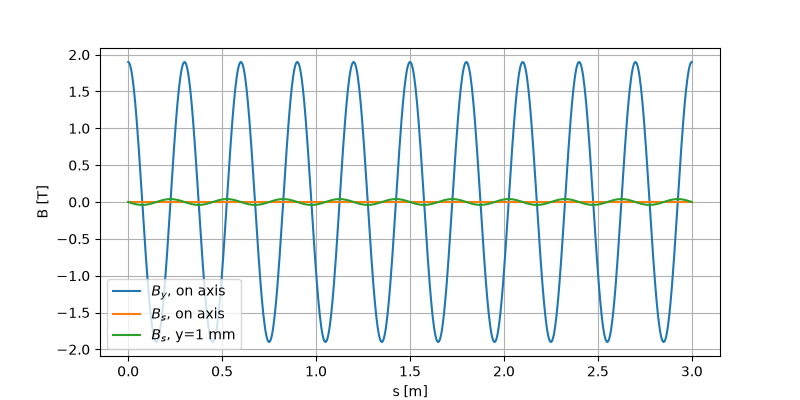

In [4]:
# ============================================================
# 5. Inspect the field
# ============================================================
# get_field(x, y, s_local) uses local s inside each element.
# This helper gets the field along the full wiggler.

def get_field_along_line(line, x=0.0, y=0.0, n_per_element=10):
    ss_all = []
    B_all = []

    s_offset = 0.0

    for elem in line.elements:
        ss_local = np.linspace(0.0, elem.length, n_per_element, endpoint=False)

        for sloc in ss_local:
            B = elem.get_field(x, y, sloc)
            ss_all.append(s_offset + sloc)
            B_all.append(B)

        s_offset += elem.length

    # include final point
    last = line.elements[-1]
    B = last.get_field(x, y, last.length)
    ss_all.append(s_offset)
    B_all.append(B)

    return np.array(ss_all), np.array(B_all)


# On-axis:
s, B_on = get_field_along_line(wiggler_sb, x=0.0, y=0.0)

# Off-axis:
s, B_off = get_field_along_line(wiggler_sb, x=0.0, y=1e-3)

plt.figure(figsize=(8, 4))
plt.plot(s, B_on[:, 1], label=r"$B_y$, on axis")
plt.plot(s, B_on[:, 2], label=r"$B_s$, on axis")
plt.plot(s, B_off[:, 2], label=r"$B_s$, y=1 mm")

plt.xlabel("s [m]")
plt.ylabel("B [T]")
plt.legend()
plt.grid(True)
plt.show()

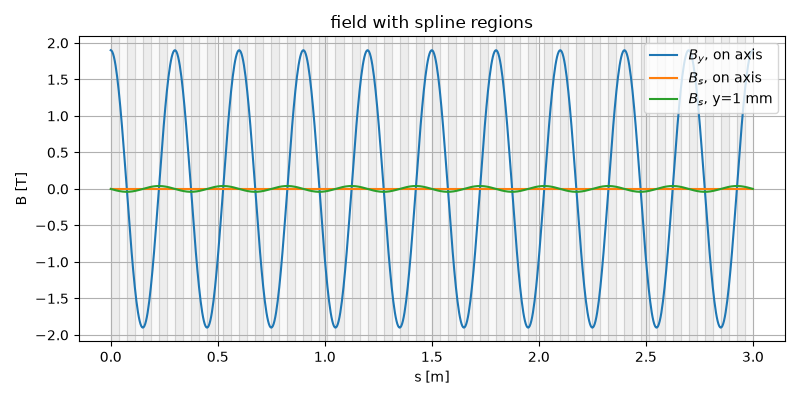

In [5]:
# ============================================================
# 5b. Inspect the field with spline regions
# ============================================================

plt.figure(figsize=(8, 4))

# Shade alternating SplineBoris elements / spline regions
for ii in range(n_splines):
    s0 = ii * L_spline
    s1 = (ii + 1) * L_spline

    plt.axvspan(
        s0, s1,
        color="0.85" if ii % 2 == 0 else "0.95",
        alpha=0.45,
        zorder=0,
    )

# Draw spline boundaries
for ii in range(n_splines + 1):
    ss = ii * L_spline
    plt.axvline(ss, color="0.65", lw=0.4, alpha=0.6, zorder=1)


plt.plot(s, B_on[:, 1], label=r"$B_y$, on axis", zorder=3)
plt.plot(s, B_on[:, 2], label=r"$B_s$, on axis", zorder=3)
plt.plot(s, B_off[:, 2], label=r"$B_s$, y=1 mm", zorder=3)

plt.xlabel("s [m]")
plt.ylabel("B [T]")
plt.title("field with spline regions")
plt.legend()
plt.grid(True, zorder=2)
plt.tight_layout()
plt.show()

In [ ]:
### Compare integrated fields ##
# sinusoidal
#s = np.linspace(0, L_wig, 20001)
By = b1(s)
# hard edge
Bp=1.905                     # [m]
lp = lambda_w / 4.0

# splineboris
By_on = B_on[:, 1]

#print("int By ds =", np.trapezoid(By, s)) ## is 0
print("sinusoid: int abs(By) ds =", np.trapezoid(np.abs(By), s))

print("hard edge: Bp*lp =", 20 * Bp * lp)

#print("SplineBoris int By ds       =", np.trapezoid(By_on, s)) ## is 0
print("SplineBoris int abs(By) ds  =", np.trapezoid(np.abs(By_on), s))

sinusoid: int abs(By) ds = 3.6268671900583964
hard edge: Bp*lp = 2.8575
SplineBoris int abs(By) ds  = 3.62686718722592


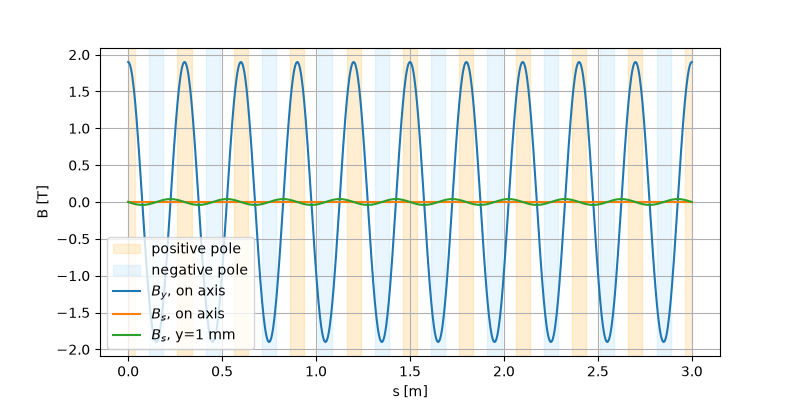

In [7]:
# ============================================================
# 6. Plot with hard-edge regions shaded
# ============================================================
plt.figure(figsize=(8, 4))

Lpole = lambda_w / 4
Ldrift = lambda_w / 4

s_cursor = 0.0
pos_done = False
neg_done = False

# initial + half pole
plt.axvspan(
    s_cursor, s_cursor + Lpole/2,
    color="orange", alpha=0.15,
    label="positive pole"
)
pos_done = True
s_cursor += Lpole/2

# drift left unshaded
s_cursor += Ldrift

# 19 alternating full poles + drifts
for ii in range(19):
    sign = -1 if (ii % 2 == 0) else +1

    if sign > 0:
        label = None if pos_done else "positive pole"
        pos_done = True
        color = "orange"
    else:
        label = None if neg_done else "negative pole"
        neg_done = True
        color = "lightskyblue"

    plt.axvspan(
        s_cursor, s_cursor + Lpole,
        color=color, alpha=0.18,
        label=label
    )

    s_cursor += Lpole
    s_cursor += Ldrift

# final + half pole
plt.axvspan(
    s_cursor, s_cursor + Lpole/2,
    color="orange", alpha=0.15
)
s_cursor += Lpole/2

plt.plot(s, B_on[:, 1], label=r"$B_y$, on axis")
plt.plot(s, B_on[:, 2], label=r"$B_s$, on axis")
plt.plot(s, B_off[:, 2], label=r"$B_s$, y=1 mm")

plt.xlabel("s [m]")
plt.ylabel("B [T]")
plt.legend()
plt.grid(True)
plt.show()

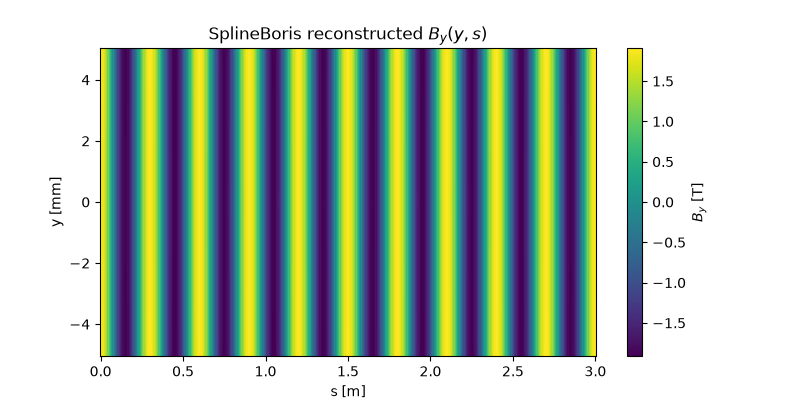

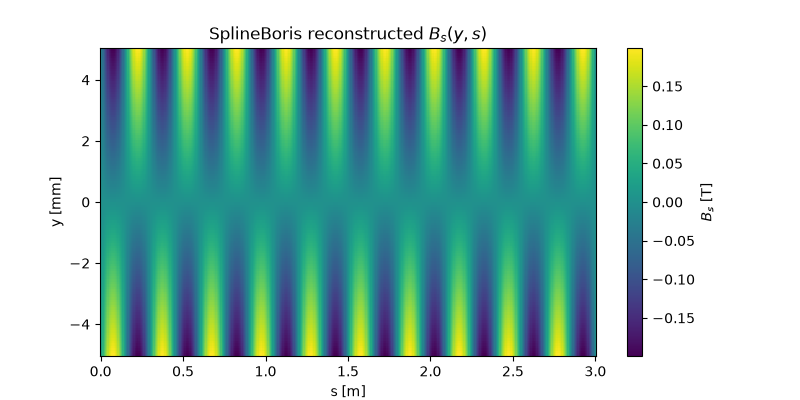

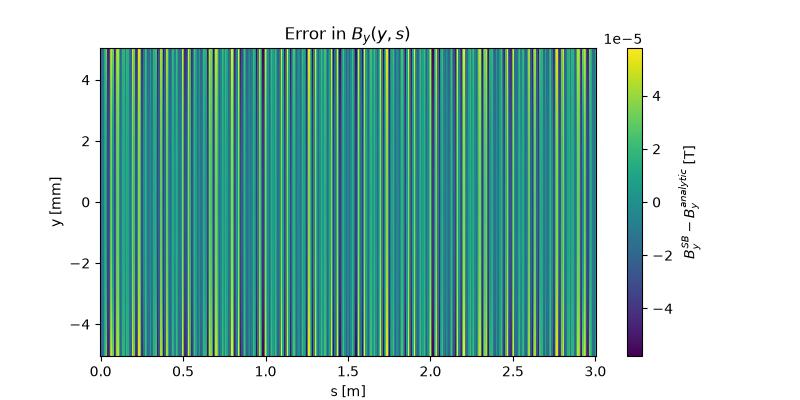

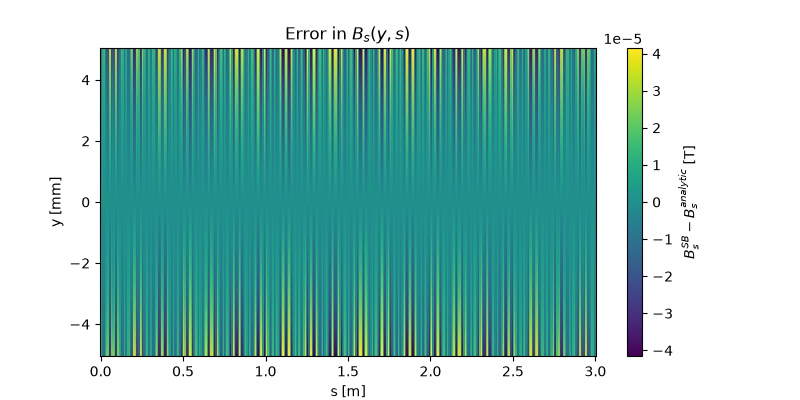

In [8]:
# ============================================================
# 7. Check reconstructed field in the (y, s) plane
# ============================================================

def get_field_at_s_global(line, x, y, s_global):
    """Evaluate field at global s by finding the corresponding SplineBoris piece."""
    s_left = 0.0

    for elem in line.elements:
        s_right = s_left + elem.length

        if s_global <= s_right:
            return np.array(elem.get_field(x, y, s_global - s_left))

        s_left = s_right

    return np.array(line.elements[-1].get_field(x, y, line.elements[-1].length))


# Grid in longitudinal and vertical coordinates
s_grid = np.linspace(0.0, L_wig, 400)
y_grid = np.linspace(-5e-3, 5e-3, 120)  # +/- 5 mm

S, Y = np.meshgrid(s_grid, y_grid)

By_num = np.zeros_like(S)
Bs_num = np.zeros_like(S)

for iy, yy in enumerate(y_grid):
    for is_, ss in enumerate(s_grid):
        B = get_field_at_s_global(wiggler_sb, x=0.0, y=yy, s_global=ss)
        By_num[iy, is_] = B[1]
        Bs_num[iy, is_] = B[2]


# Analytic ideal planar-undulator field
By_th = Bw * np.cosh(k * Y) * np.cos(k * S)  
Bs_th = -Bw * np.sinh(k * Y) * np.sin(k * S)


# Plot reconstructed By(y,s)
plt.figure(figsize=(8, 4))
plt.pcolormesh(s_grid, 1e3*y_grid, By_num, shading="auto")
plt.colorbar(label=r"$B_y$ [T]")
plt.xlabel("s [m]")
plt.ylabel("y [mm]")
plt.title(r"SplineBoris reconstructed $B_y(y,s)$")
plt.show()


# Plot reconstructed Bs(y,s)
plt.figure(figsize=(8, 4))
plt.pcolormesh(s_grid, 1e3*y_grid, Bs_num, shading="auto")
plt.colorbar(label=r"$B_s$ [T]")
plt.xlabel("s [m]")
plt.ylabel("y [mm]")
plt.title(r"SplineBoris reconstructed $B_s(y,s)$")
plt.show()


# Plot error against analytic planar-undulator expression
plt.figure(figsize=(8, 4))
plt.pcolormesh(s_grid, 1e3*y_grid, By_num - By_th, shading="auto")
plt.colorbar(label=r"$B_y^{SB}-B_y^{analytic}$ [T]")
plt.xlabel("s [m]")
plt.ylabel("y [mm]")
plt.title(r"Error in $B_y(y,s)$")
plt.show()

plt.figure(figsize=(8, 4))
plt.pcolormesh(s_grid, 1e3*y_grid, Bs_num - Bs_th, shading="auto")
plt.colorbar(label=r"$B_s^{SB}-B_s^{analytic}$ [T]")
plt.xlabel("s [m]")
plt.ylabel("y [mm]")
plt.title(r"Error in $B_s(y,s)$")
plt.show()

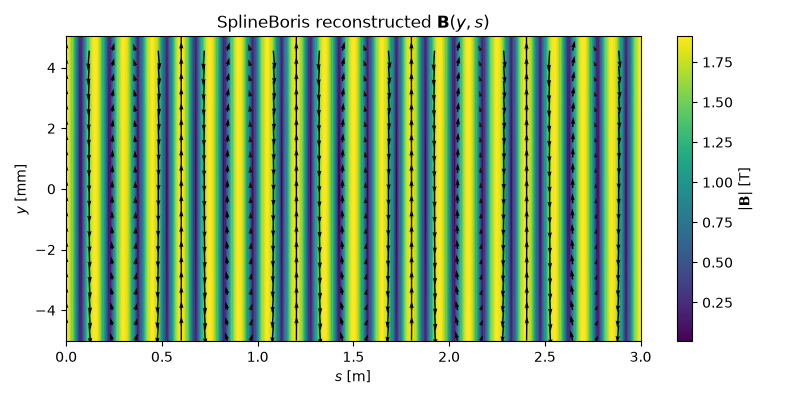

In [9]:
# ============================================================
# 8. Plot B in the (y, s) plane
# ============================================================

s_grid = np.linspace(0.0, L_wig, 500)
y_grid = np.linspace(-5e-3, 5e-3, 160)

S, Y = np.meshgrid(s_grid, y_grid)

By = np.zeros_like(S)
Bs = np.zeros_like(S)
Bmag = np.zeros_like(S)

for iy, yy in enumerate(y_grid):
    for is_, ss in enumerate(s_grid):
        B = get_field_at_s_global(wiggler_sb, x=0.0, y=yy, s_global=ss)
        By[iy, is_] = B[1]
        Bs[iy, is_] = B[2]
        Bmag[iy, is_] = np.sqrt(B[0]**2 + B[1]**2 + B[2]**2)

plt.figure(figsize=(8, 4))

plt.pcolormesh(
    s_grid,
    1e3*y_grid,
    Bmag,
    shading="auto",
)

plt.colorbar(label=r"$|\mathbf{B}|$ [T]")

skip_s = 20
skip_y = 8

plt.quiver(
    S[::skip_y, ::skip_s],
    1e3*Y[::skip_y, ::skip_s],
    Bs[::skip_y, ::skip_s],       # horizontal arrow component: along s
    By[::skip_y, ::skip_s],       # vertical arrow component: along y
    color="k",
    scale=45,
    width=0.0025,
)

plt.xlabel(r"$s$ [m]")
plt.ylabel(r"$y$ [mm]")
plt.title(r"SplineBoris reconstructed $\mathbf{B}(y,s)$")
plt.tight_layout()
plt.show()